# ESM-2 蛋白语言模型：药物靶点表征与相似性分析

本项目用 Meta 的 **ESM-2** 蛋白语言模型（Protein Language Model, pLM）对 16 个抗癌药物靶点蛋白
生成嵌入向量，并完成**相似度计算、层次聚类与降维可视化**，验证一条核心假设：

> 仅凭蛋白序列（**完全无标签**），语言模型学到的嵌入就能反映蛋白家族 / 功能关系——
> 同类（尤其都是激酶）的靶点在嵌入空间中更接近。

分析流程：`读取序列 → ESM-2 编码 → 平均池化 → 余弦相似度 → 聚类热图 → PCA/t-SNE 可视化`。

## 背景：什么是蛋白语言模型？

蛋白质由 20 种氨基酸按顺序组成。把氨基酸当作「字母」、整条序列当作「句子」，
ESM-2 这类模型用类似 BERT 的 **Transformer** 架构，在千万级蛋白序列上做自监督预训练
（预测被随机遮挡的氨基酸）。训练完成后，模型内部的隐层向量就是对序列的**表征（embedding）**，
编码越接近的蛋白，往往结构与功能越相近——这正是本项目要验证的。

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# 定位项目根目录（含 src/ 的目录），保证从任意目录启动 Jupyter 都能找到模块
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "src" / "embed_targets.py").exists():
        PROJECT_ROOT = _p
        break
else:
    PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.embed_targets import (
    setup_huggingface_env, read_fasta, read_metadata,
    load_model, embed_proteins, cosine_similarity, save_embeddings,
)

# 中文字体，避免图表中文显示为方块
matplotlib.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

print("项目根目录:", PROJECT_ROOT)

D:\python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


项目根目录: C:\Users\lenovo\esm2_drug_targets


## 1. 加载数据

16 条序列来自 UniProt 真实标准序列，覆盖受体/非受体酪氨酸激酶、丝/苏氨酸激酶、
小 GTPase 与其他酶 5 个家族。

In [2]:
fasta_path = PROJECT_ROOT / "data" / "drug_targets.fasta"
meta_path = PROJECT_ROOT / "data" / "drug_targets_metadata.csv"

sequences = read_fasta(fasta_path)
names = list(sequences.keys())
meta = pd.read_csv(meta_path).set_index("gene").loc[names].reset_index()

print(f"共 {len(sequences)} 条蛋白序列")
print()
print(meta[["gene", "uniprot", "family", "length"]].to_string(index=False))

共 16 条蛋白序列

 gene uniprot                    family  length
 EGFR  P00533     Tyrosine kinase (RTK)    1210
ERBB2  P04626     Tyrosine kinase (RTK)    1255
  KDR  P35968     Tyrosine kinase (RTK)    1356
  ALK  Q9UM73     Tyrosine kinase (RTK)    1620
 FLT3  P36888     Tyrosine kinase (RTK)     993
 ABL1  P00519 Tyrosine kinase (non-RTK)    1130
  SRC  P12931 Tyrosine kinase (non-RTK)     536
  BTK  Q06187 Tyrosine kinase (non-RTK)     659
 JAK2  O60674 Tyrosine kinase (non-RTK)    1132
 BRAF  P15056            Ser/Thr kinase     766
MAPK1  P28482            Ser/Thr kinase     360
 CDK4  P11802            Ser/Thr kinase     303
 CDK6  Q00534            Ser/Thr kinase     326
 KRAS  P01116              Small GTPase     189
 ACE2  Q9BYF1              Other enzyme     805
PARP1  P09874              Other enzyme    1014


## 2. 加载 ESM-2 模型

默认使用最小的 `esm2_t6_8M`（约 32MB），CPU 即可秒级加载，保证**可复现**；
换成 `esm2_t33_650M`（约 2.6GB）可得到更高质量嵌入（需 ~8GB 以上可用内存）。
代码会自动设置 `HF_ENDPOINT` 镜像并复用本地缓存。

In [3]:
MODEL_NAME = "facebook/esm2_t6_8M_UR50D"   # 可换成 facebook/esm2_t33_650M_UR50D

setup_huggingface_env()
model, tokenizer, device = load_model(MODEL_NAME)

print(f"模型: {MODEL_NAME}")
print(f"设备: {device}")
print(f"参数量: {sum(p.numel() for p in model.parameters()) / 1e6:.1f} M")
print(f"嵌入维度: {model.config.hidden_size}")
print(f"最大序列长度: {model.config.max_position_embeddings}")

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 102/102 [00:00<00:00, 6932.96it/s]


[transformers] EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


模型: facebook/esm2_t6_8M_UR50D
设备: cpu
参数量: 7.5 M
嵌入维度: 320
最大序列长度: 1026


## 3. 生成蛋白嵌入

对每条序列做前向传播，得到每个残基的隐向量后**平均池化**成一个蛋白级向量。
长度超过模型窗口（1024 残基）的序列会**切窗嵌入再平均**，避免简单截断丢掉 C 端信息。

In [4]:
embeddings = embed_proteins(model, tokenizer, [sequences[n] for n in names], device)

print(f"嵌入矩阵形状: {embeddings.shape}  (蛋白数 × 维度)")

# 保存嵌入以便复现
os.makedirs(PROJECT_ROOT / "results", exist_ok=True)
save_embeddings(PROJECT_ROOT / "results" / "embeddings.npz", embeddings, names)
print("已保存: results/embeddings.npz")

嵌入矩阵形状: (16, 320)  (蛋白数 × 维度)
已保存: results/embeddings.npz


## 4. 相似度矩阵 + 层次聚类热图

对嵌入做 L2 归一化后求内积，即**余弦相似度**（1 = 完全相同，0 = 无关）。
热图同时展示相似度数值与层次聚类的树状图，行/列按家族着色。

> 蛋白语言模型的嵌入存在较高的相似度「基线」（本数据多在 0.7 以上），
> 因此热图色标缩放到 **0.65 ~ 1.0**，以突出相对差异而非绝对数值。

In [5]:
# ---- 配色：色盲友好的分类色 + 蓝色渐变色带 ----
FAMILY_COLORS = {
    "Tyrosine kinase (RTK)":     "#2a78d6",  # 蓝
    "Tyrosine kinase (non-RTK)": "#eb6834",  # 橙
    "Ser/Thr kinase":            "#1baf7a",  # 青
    "Small GTPase":              "#eda100",  # 黄
    "Other enzyme":              "#e87ba4",  # 品红
}
blue_cmap = LinearSegmentedColormap.from_list(
    "blue_ramp", ["#cde2fb", "#86b6ef", "#3987e5", "#2a78d6", "#184f95", "#0d366b"]
)

# ---- 余弦相似度矩阵 ----
sim = cosine_similarity(embeddings)
sim_df = pd.DataFrame(sim, index=names, columns=names)

family_map = dict(zip(meta["gene"], meta["family"]))
row_colors = [FAMILY_COLORS[family_map[n]] for n in names]

print("相似度矩阵（前 6×6）：")
print(sim_df.round(3).iloc[:6, :6])

相似度矩阵（前 6×6）：
        EGFR  ERBB2    KDR    ALK   FLT3   ABL1
EGFR   1.000  0.971  0.945  0.964  0.936  0.960
ERBB2  0.971  1.000  0.930  0.970  0.913  0.954
KDR    0.945  0.930  1.000  0.954  0.982  0.926
ALK    0.964  0.970  0.954  1.000  0.952  0.964
FLT3   0.936  0.913  0.982  0.952  1.000  0.914
ABL1   0.960  0.954  0.926  0.964  0.914  1.000


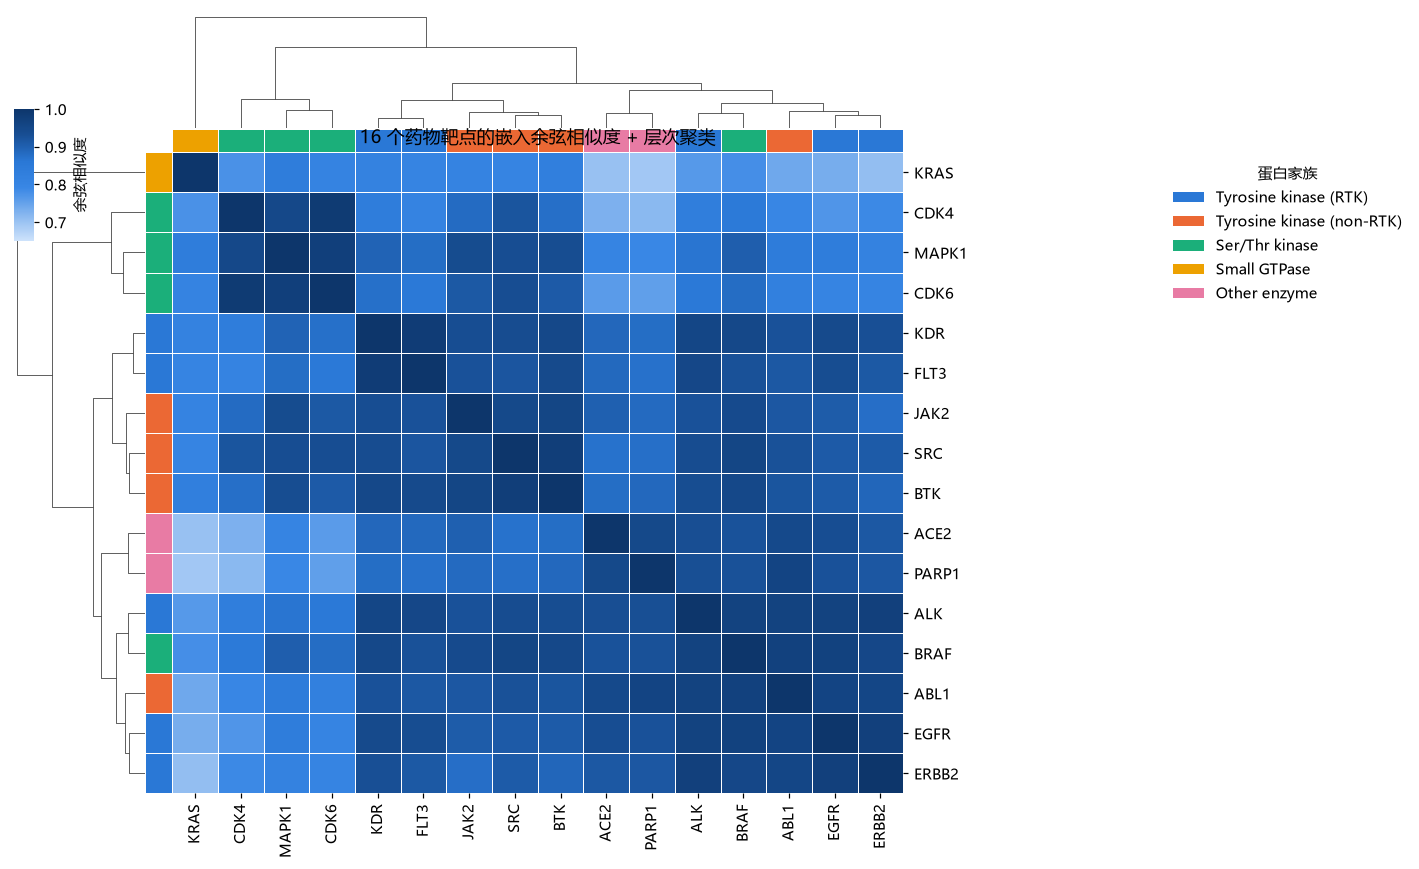

In [6]:
g = sns.clustermap(
    sim_df,
    cmap=blue_cmap,
    vmin=0.65,
    vmax=1.0,
    row_colors=row_colors,
    col_colors=row_colors,
    figsize=(9, 8),
    dendrogram_ratio=(0.15, 0.15),
    linewidths=0.5,
    cbar_pos=(0.02, 0.72, 0.02, 0.15),
    cbar_kws={"label": "余弦相似度"},
)
g.ax_heatmap.set_title("16 个药物靶点的嵌入余弦相似度 + 层次聚类")

legend_handles = [Patch(facecolor=c, label=f) for f, c in FAMILY_COLORS.items()]
g.ax_heatmap.legend(
    handles=legend_handles,
    title="蛋白家族",
    bbox_to_anchor=(1.35, 1.0),
    loc="upper left",
    frameon=False,
)
g.savefig(PROJECT_ROOT / "results" / "similarity_clustermap.png", dpi=130, bbox_inches="tight")
plt.show()

## 5. 降维可视化（PCA 与 t-SNE）

高维向量肉眼无法直接看，用 PCA（主成分分析，线性）和 t-SNE（非线性流形学习）投影到二维，
按家族着色观察聚类是否与生物学一致。

In [7]:
# 标准化后做 PCA（PCA 对方差尺度敏感，先标准化）
X = StandardScaler().fit_transform(embeddings)

pca = PCA(n_components=2, random_state=42)
Z_pca = pca.fit_transform(X)
print(f"PCA 前两个主成分解释方差比: {pca.explained_variance_ratio_.round(3)}")
print(f"累计解释方差: {pca.explained_variance_ratio_.sum():.3f}")

tsne = TSNE(n_components=2, perplexity=5, random_state=42, init="pca")
Z_tsne = tsne.fit_transform(X)
print("t-SNE 完成")

PCA 前两个主成分解释方差比: [0.273 0.155]
累计解释方差: 0.427


t-SNE 完成


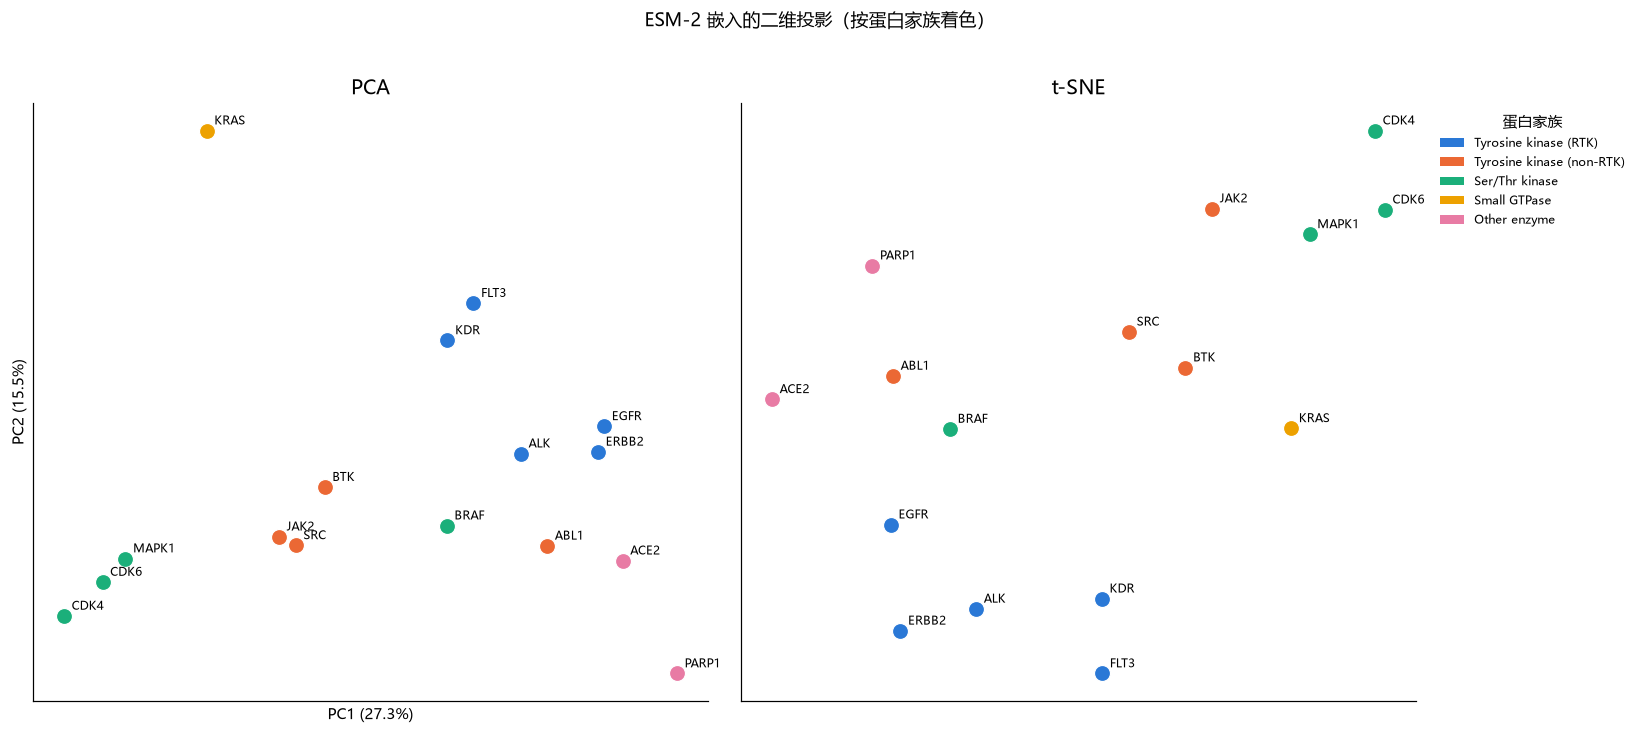

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

for ax, Z, title in [(axes[0], Z_pca, "PCA"), (axes[1], Z_tsne, "t-SNE")]:
    for fam in FAMILY_COLORS:
        idx = meta["family"].values == fam
        ax.scatter(Z[idx, 0], Z[idx, 1], s=110, color=FAMILY_COLORS[fam],
                   edgecolor="white", linewidth=0.8)
    for i, n in enumerate(names):
        ax.annotate(n, (Z[i, 0], Z[i, 1]), textcoords="offset points",
                    xytext=(5, 4), fontsize=8)
    ax.set_title(title, fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")

handles = [Patch(facecolor=c, label=f) for f, c in FAMILY_COLORS.items()]
axes[1].legend(handles=handles, title="蛋白家族", fontsize=8,
               frameon=False, bbox_to_anchor=(1.02, 1.0), loc="upper left")

fig.suptitle("ESM-2 嵌入的二维投影（按蛋白家族着色）", y=1.02)
plt.tight_layout()
fig.savefig(PROJECT_ROOT / "results" / "projection_families.png", dpi=130, bbox_inches="tight")
plt.show()

## 6. 相似靶点查询：以 EGFR 为例

在实际药物研发中，「找与已知靶点最相似的其他蛋白」可用于**发现新靶点**或**预测脱靶**。
下面查询与 EGFR（肺癌常见靶点）最相似的蛋白。

In [9]:
query = "EGFR"
qi = names.index(query)

order = np.argsort(-sim[qi])  # 按相似度降序
rows = []
for j in order:
    if j == qi:
        continue
    rows.append({"靶点": names[j], "家族": family_map[names[j]], "相似度": round(sim[qi, j], 3)})
top = pd.DataFrame(rows).head(6)

print(f"与 {query} 最相似的靶点：")
print(top.to_string(index=False))

与 EGFR 最相似的靶点：
   靶点                        家族   相似度
ERBB2     Tyrosine kinase (RTK) 0.971
 BRAF            Ser/Thr kinase 0.967
  ALK     Tyrosine kinase (RTK) 0.964
 ABL1 Tyrosine kinase (non-RTK) 0.960
  KDR     Tyrosine kinase (RTK) 0.945
 FLT3     Tyrosine kinase (RTK) 0.936


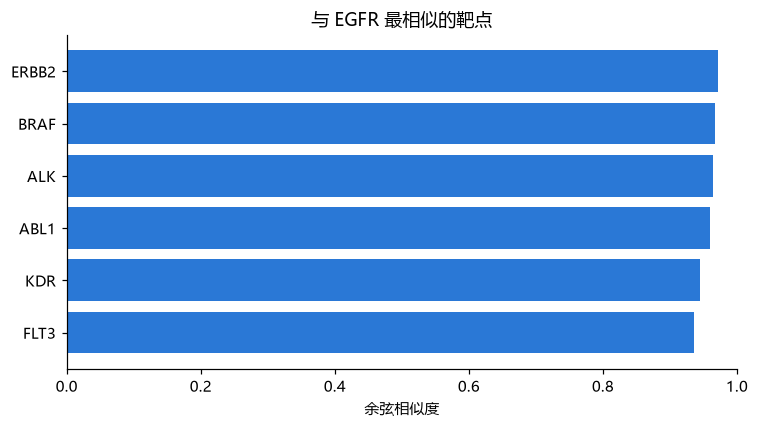

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
d = top.iloc[::-1]  # 反转使最大值在顶部
ax.barh(d["靶点"], d["相似度"], color="#2a78d6")
ax.set_xlabel("余弦相似度")
ax.set_title(f"与 {query} 最相似的靶点")
ax.set_xlim(0, 1)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
fig.savefig(PROJECT_ROOT / "results" / "top_similar_egfr.png", dpi=130, bbox_inches="tight")
plt.show()

## 结论

- **激酶类靶点**（受体/非受体酪氨酸激酶 + 丝/苏氨酸激酶）在嵌入空间中聚成明显一簇；
- **非激酶**（ACE2、PARP1）与**小 GTPase**（KRAS）与激酶显著分开；
- 说明 ESM-2 在**完全无监督**条件下，仅凭序列就学到了「蛋白家族」这一生物学结构。

